# Mini-Proyecto de generación de texto con GPT
## Fine-tuning de un modelo preentrenado para generación de párrafos jurídicos en español

**Estudiantes:** Juan Manuel Hurtado Angulo - Manuel Alberto Gonzalez Gonzalez - William Alberto Reina García  
**Curso:** Procesamiento de Lenguaje Natural  
**Profesor:** Luis Eduardo Ferro Diez  

Este notebook construye un **corpus jurídico real** a partir de fuentes oficiales de Colombia, entrena un modelo GPT pequeño en español y compara la generación **antes y después** del fine-tuning usando:
- **decodificación greedy**
- **muestreo (sample)**
- una **función propia de generación**
- la función nativa `model.generate()` de Hugging Face

## Objetivo del mini-proyecto

Adaptar un modelo GPT preentrenado a un corpus jurídico real en español para observar cómo cambia su estilo de generación, comparando el modelo base contra el modelo ajustado y analizando el efecto de hiperparámetros como `temperature`, `top_k`, `top_p` y `eps`.

## 1. Instalación de dependencias

In [1]:
!pip -q install transformers datasets accelerate sentencepiece beautifulsoup4 lxml evaluate

## 2. Importación de librerías y configuración

In [2]:
import os
import re
import math
import time
import random
import warnings
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

import torch
import torch.nn.functional as F

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 3. Construcción del dataset jurídico real

Aquí se construye un corpus con **normas reales** tomadas de sitios oficiales colombianos.

### Fuentes oficiales usadas
- Constitución Política de 1991  
- Ley 80 de 1993   
- Ley 70 de 1993    
- Ley 160 de 1994    
- Ley 100 de 1993    

In [3]:
LEGAL_SOURCES = [
    {
        "name": "Constitucion_Politica_1991",
        "url": "https://colombia.justia.com/nacionales/constitucion-politica-de-colombia/titulo-i/"
    },
    {
        "name": "Ley_80_1993",
        "url": "https://relatoria.colombiacompra.gov.co/normativa/ley-80-de-1993/"
    },
    {
        "name": "Ley_70_1993",
        "url": "http://www.secretariasenado.gov.co/senado/basedoc/ley_0070_1993.html"
    },
    {
        "name": "Ley_160_1994",
        "url": "http://www.secretariasenado.gov.co/senado/basedoc/ley_0160_1994.html"
    },
    {
        "name": "Ley_100_1993",
        "url": "http://www.secretariasenado.gov.co/senado/basedoc/ley_0100_1993.html"
    }
]

pd.DataFrame(LEGAL_SOURCES)

,name,url
0,Constitucion_Politica_1991,https://colombia.justia.com/nacionales/constit...
1,Ley_80_1993,https://relatoria.colombiacompra.gov.co/normat...
2,Ley_70_1993,http://www.secretariasenado.gov.co/senado/base...
3,Ley_160_1994,http://www.secretariasenado.gov.co/senado/base...
4,Ley_100_1993,http://www.secretariasenado.gov.co/senado/base...


### Funciones auxiliares para descarga, limpieza y segmentación

Estas funciones:
1. descargan el HTML,
2. extraen el texto principal,
3. limpian elementos repetitivos,
4. dividen el contenido en fragmentos con tamaño útil para lenguaje jurídico.

In [4]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome Safari/537.36"
}

def download_html(url: str, timeout: int = 40) -> str:
    response = requests.get(url, headers=HEADERS, timeout=timeout)
    response.raise_for_status()
    response.encoding = response.apparent_encoding
    return response.text

def clean_legal_text(text: str) -> str:
    text = re.sub(r"\r", " ", text)
    text = re.sub(r"\t", " ", text)
    text = re.sub(r"\xa0", " ", text)
    text = re.sub(r"[ ]{2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    # Limpieza de frases frecuentes no deseadas
    patterns_to_remove = [
        r"Descargar PDF",
        r"Imprimir",
        r"Notas de Vigencia",
        r"Jurisprudencia Vigencia",
        r"Legislación Anterior",
        r"Diario Oficial No\.[^\n]+",
        r"EL CONGRESO DE COLOMBIA",
        r"EL PRESIDENTE DE LA REPÚBLICA DE COLOMBIA",
    ]
    for p in patterns_to_remove:
        text = re.sub(p, " ", text, flags=re.IGNORECASE)

    text = re.sub(r"[ ]{2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text

def html_to_visible_text(html: str) -> str:
    soup = BeautifulSoup(html, "lxml")

    for tag in soup(["script", "style", "noscript", "header", "footer", "svg"]):
        tag.decompose()

    text = soup.get_text("\n")
    text = clean_legal_text(text)
    return text

def split_into_legal_chunks(text: str,
                            min_chars: int = 250,
                            max_chars: int = 1200) -> List[str]:
    # Primero intentamos partir por artículos, secciones y saltos fuertes
    candidates = re.split(
        r"(?=(?:ART[IÍ]CULO|Artículo|CAP[IÍ]TULO|Capítulo|SECCI[OÓ]N|Sección|T[IÍ]TULO|Título)\b)",
        text
    )

    chunks = []
    buffer = ""

    for part in candidates:
        part = re.sub(r"\s+", " ", part).strip()
        if len(part) < 80:
            continue

        if len(part) > max_chars * 1.8:
            # subdividir textos muy largos por puntuación
            subparts = re.split(r"(?<=[\.;:])\s+", part)
        else:
            subparts = [part]

        for sub in subparts:
            sub = sub.strip()
            if len(sub) < 80:
                continue

            if len(buffer) + len(sub) + 1 <= max_chars:
                buffer = f"{buffer} {sub}".strip()
            else:
                if len(buffer) >= min_chars:
                    chunks.append(buffer)
                buffer = sub

    if len(buffer) >= min_chars:
        chunks.append(buffer)

    # limpieza final
    final_chunks = []
    seen = set()
    for c in chunks:
        c = re.sub(r"\s+", " ", c).strip()
        if min_chars <= len(c) <= max_chars * 1.5 and c not in seen:
            final_chunks.append(c)
            seen.add(c)

    return final_chunks

def build_legal_corpus(sources: List[Dict]) -> pd.DataFrame:
    records = []

    for source in sources:
        print(f"Procesando: {source['name']}")
        html = download_html(source["url"])
        text = html_to_visible_text(html)
        chunks = split_into_legal_chunks(text)

        print(f"  Fragmentos útiles: {len(chunks)}")
        for idx, chunk in enumerate(chunks):
            records.append({
                "source": source["name"],
                "url": source["url"],
                "chunk_id": idx,
                "text": chunk
            })

    df = pd.DataFrame(records)
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    return df

### Descargar y construir el corpus

In [5]:
df = build_legal_corpus(LEGAL_SOURCES)
print("Total de fragmentos:", len(df))
df.head()

Procesando: Constitucion_Politica_1991
  Fragmentos útiles: 6
Procesando: Ley_80_1993
  Fragmentos útiles: 136
Procesando: Ley_70_1993
  Fragmentos útiles: 32
Procesando: Ley_160_1994
  Fragmentos útiles: 55
Procesando: Ley_100_1993
  Fragmentos útiles: 63
Total de fragmentos: 292


,source,url,chunk_id,text
0,Constitucion_Politica_1991,https://colombia.justia.com/nacionales/constit...,0,TÍTULO I :: Ley de Colombia Justia Colombia Na...
1,Constitucion_Politica_1991,https://colombia.justia.com/nacionales/constit...,1,ARTICULO 2º—Son fines esenciales del Estado: s...
2,Constitucion_Politica_1991,https://colombia.justia.com/nacionales/constit...,2,ARTICULO 4º—La Constitución es norma de normas...
3,Constitucion_Politica_1991,https://colombia.justia.com/nacionales/constit...,3,ARTICULO 9º—Las relaciones exteriores del Esta...
4,Constitucion_Politica_1991,https://colombia.justia.com/nacionales/constit...,4,"— Pacto de Integración Subregional Andino, sus..."


### Guardar el dataset generado

In [6]:
dataset_path = "/content/corpus_juridico_real_colombia.csv"
df.to_csv(dataset_path, index=False, encoding="utf-8")
print("Dataset guardado en:", dataset_path)

Dataset guardado en: /content/corpus_juridico_real_colombia.csv


## 4. Exploración del corpus

In [7]:
df["num_chars"] = df["text"].str.len()
df["num_words"] = df["text"].str.split().apply(len)

display(df[["source", "num_chars", "num_words"]].head())
display(df[["num_chars", "num_words"]].describe())

,source,num_chars,num_words
0,Constitucion_Politica_1991,470,71
1,Constitucion_Politica_1991,1028,159
2,Constitucion_Politica_1991,1075,171
3,Constitucion_Politica_1991,1028,163
4,Constitucion_Politica_1991,1141,194


,num_chars,num_words
count,292.000000,292.000000
mean,1012.147260,159.684932
std,255.055514,41.099369
min,295.000000,51.000000
25%,877.750000,140.000000
50%,1049.500000,164.000000
75%,1156.500000,180.250000
max,1788.000000,306.000000


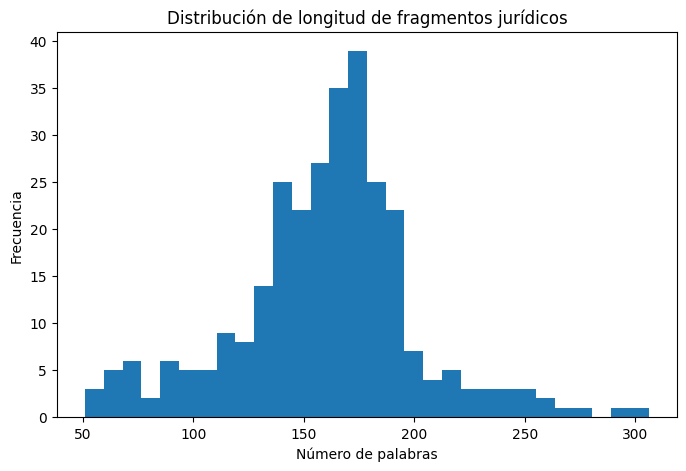

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["num_words"], bins=30)
plt.title("Distribución de longitud de fragmentos jurídicos")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

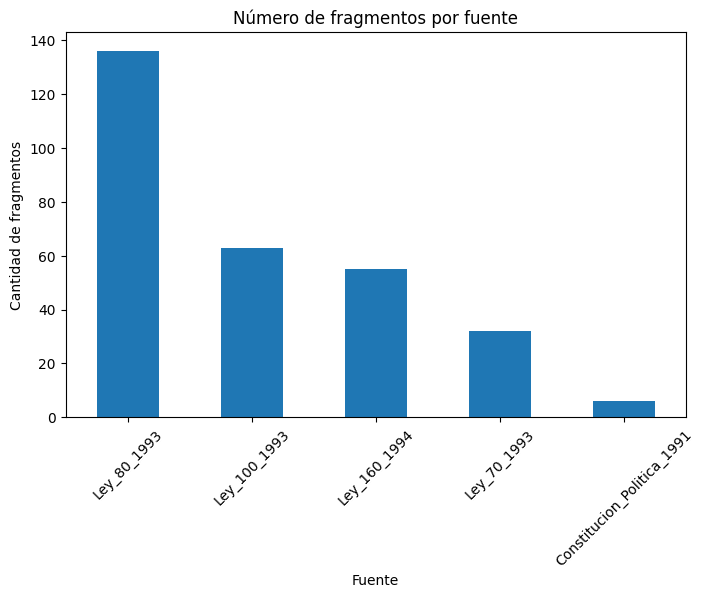

In [9]:
plt.figure(figsize=(8,5))
df["source"].value_counts().plot(kind="bar")
plt.title("Número de fragmentos por fuente")
plt.xlabel("Fuente")
plt.ylabel("Cantidad de fragmentos")
plt.xticks(rotation=45)
plt.show()

In [10]:
for i in range(3):
    print(f"\n--- EJEMPLO {i+1} ---")
    print("Fuente:", df.loc[i, "source"])
    print(df.loc[i, "text"][:1200])


--- EJEMPLO 1 ---
Fuente: Constitucion_Politica_1991
TÍTULO I :: Ley de Colombia Justia Colombia Nacionales Constitución Política De Colombia ARTICULO 1º—Colombia es un Estado social de derecho organizado en forma de República unitaria, descentralizada, con autonomía de sus entidades territoriales, democrática, participativa y pluralista, fundada en el respeto de la dignidad humana, en el trabajo y la solidaridad de las personas que la integran y en la prevalencia del interés general. Volver al inicio Volver al indice

--- EJEMPLO 2 ---
Fuente: Constitucion_Politica_1991
ARTICULO 2º—Son fines esenciales del Estado: servir a la comunidad, promover la prosperidad general y garantizar la efectividad de los principios, derechos y deberes consagrados en la Constitución; facilitar la participación de todos en las decisiones que los afectan y en la vida económica, política, administrativa y cultural de la Nación; defender la independencia nacional, mantener la integridad territorial y asegur

## 5. Carga del modelo GPT base

Se utiliza un modelo pequeño en español para que sea viable en Colab con GPU T4.

In [11]:
model_name = "datificate/gpt2-small-spanish"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_base = AutoModelForCausalLM.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_base.config.pad_token_id = tokenizer.pad_token_id
model_base = model_base.to(device)

print("Modelo cargado:", model_name)
print("Vocab size:", tokenizer.vocab_size)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: datificate/gpt2-small-spanish
Vocab size: 50257


## 6. Generación inicial con el modelo base

In [12]:
prompts = [
    "Artículo primero:",
    "La presente ley tiene por objeto",
    "Se resuelve que",
    "De conformidad con lo dispuesto en",
]

for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = model_base.generate(
        **inputs,
        max_length=120,
        do_sample=False
    )
    print("\n" + "="*100)
    print("PROMPT:", prompt)
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



PROMPT: Artículo primero:
Artículo primero:























































































































Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



PROMPT: La presente ley tiene por objeto
La presente ley tiene por objeto la protección de los derechos de los ciudadanos, la libertad de expresión, la libertad de prensa, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de los medios de comunicación, la libertad de expresión de


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



PROMPT: Se resuelve que
Se resuelve que la población de la ciudad de San Juan de la Frontera, en la provincia de Cádiz, se encuentra en una situación de extrema pobreza.

La ciudad de San Juan de la Frontera, en la provincia de Cádiz, se encuentra en una situación de extrema pobreza.

La ciudad de San Juan de la Frontera, en la provincia de Cádiz, se encuentra en una situación de extrema pobreza.

La ciudad de San Juan de la Frontera, en la provincia de Cádiz, se encuentra en una situación de extrema pobreza.

La ciudad de San Juan de la Frontera, en

PROMPT: De conformidad con lo dispuesto en
De conformidad con lo dispuesto en la Ley de Régimen Electoral General, que establece el número de concejales elegibles en función de la población del municipio, la Corporación Municipal de la ciudad de León está formada por los siguientes concejales:

Local:

Federal:






































































## 7. Implementación de una función propia de generación

La lógica es:
- con probabilidad `eps`, elegir el token de mayor probabilidad (**greedy**),
- con probabilidad `1 - eps`, hacer **muestreo**.

Así, por ejemplo, `eps=0.9` significa una generación mayoritariamente greedy pero con algo de exploración.

In [13]:
def generate_custom(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 80,
    temperature: float = 1.0,
    top_k: int = 0,
    eps: float = 1.0,
    device: str = "cpu",
) -> str:
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(input_ids=input_ids)
            logits = outputs.logits[:, -1, :]

            if temperature != 1.0:
                logits = logits / temperature

            probs = F.softmax(logits, dim=-1)

            if top_k > 0:
                top_probs, top_idx = torch.topk(probs, top_k)
                filtered_probs = torch.zeros_like(probs)
                filtered_probs.scatter_(1, top_idx, top_probs)
                probs = filtered_probs / filtered_probs.sum(dim=-1, keepdim=True)

            if random.random() < eps:
                next_token = torch.argmax(probs, dim=-1, keepdim=True)
            else:
                next_token = torch.multinomial(probs, num_samples=1)

            input_ids = torch.cat([input_ids, next_token], dim=1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

In [14]:
for cfg in [
    {"temperature": 0.8, "top_k": 20, "eps": 1.0},
    {"temperature": 0.9, "top_k": 30, "eps": 0.9},
    {"temperature": 1.0, "top_k": 50, "eps": 0.7},
]:
    print("\n" + "#"*100)
    print("Configuración:", cfg)
    print(generate_custom(
        model=model_base,
        tokenizer=tokenizer,
        prompt="Artículo primero:",
        max_new_tokens=80,
        temperature=cfg["temperature"],
        top_k=cfg["top_k"],
        eps=cfg["eps"],
        device=device
    ))


####################################################################################################
Configuración: {'temperature': 0.8, 'top_k': 20, 'eps': 1.0}
Artículo primero:

















































































####################################################################################################
Configuración: {'temperature': 0.9, 'top_k': 30, 'eps': 0.9}
Artículo primero:





En el año 2000, la Universidad de California en San Diego (UCS) anunció que la Universidad de California en San Diego (UCS) había adquirido la licencia de la Universidad de California en San Diego por $1.5 millones para la construcción de un campus en el campus de la UCS. El campus se ubicó en el campus de la UCS, en

####################################################################################################
Configuración: {'temperature': 1.0, 'top_k': 50, 'eps': 0.7}
Artículo primero:


El objetivo de la investigación es determinar los e

## 8. Generación con `model.generate()` y muestreo

Aquí probamos hiperparámetros de muestreo nativos del modelo.

In [15]:
sampling_configs = [
    {"temperature": 0.7, "top_k": 20, "top_p": 0.90},
    {"temperature": 0.9, "top_k": 50, "top_p": 0.95},
    {"temperature": 1.1, "top_k": 50, "top_p": 0.98},
]

prompt = "Artículo primero:"

for cfg in sampling_configs:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = model_base.generate(
        **inputs,
        max_length=120,
        do_sample=True,
        temperature=cfg["temperature"],
        top_k=cfg["top_k"],
        top_p=cfg["top_p"],
        pad_token_id=tokenizer.eos_token_id
    )
    print("\n" + "="*100)
    print("Configuración:", cfg)
    print(tokenizer.decode(output[0], skip_special_tokens=True))


Configuración: {'temperature': 0.7, 'top_k': 20, 'top_p': 0.9}
Artículo primero:

El sistema de clasificación de la Asociación Internacional de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la Asociación de Cronistas de la

Configuración: {'temperature': 0.9, 'top_k': 50, 'top_p': 0.95}
Artículo primero:




En diciembre de 2015, las compañías de telecomunicaciones privadas y públicas de Alemania se reunieron para discutir la posibilidad de desarrollar un acuerdo de asociación entre el consorcio TIATERL y la ORF (Otto Geoprofting Systems). El acu

## 9. Preparación del dataset para fine-tuning

In [16]:
train_df = df[["text"]].copy()
dataset_hf = Dataset.from_pandas(train_df)

max_length = 128

def preprocess_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = dataset_hf.map(preprocess_function, batched=True, remove_columns=["text"])
split_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=SEED)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(train_dataset)
print(eval_dataset)

Map:   0%|          | 0/292 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 262
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 30
})


## 10. Definición del entrenamiento

In [17]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

model_ft = AutoModelForCausalLM.from_pretrained(model_name)
model_ft.config.pad_token_id = tokenizer.pad_token_id
model_ft = model_ft.to(device)

training_args = TrainingArguments(
    output_dir="/content/gpt2_juridico_results",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    processing_class=tokenizer
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 11. Fine-tuning

In [18]:
train_output = trainer.train()
train_output

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 0, 'bos_token_id': 0, 'pad_token_id': 0}.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.486178,3.313968
2,2.964187,3.211255
3,2.697770,3.160734
4,2.464245,3.145756
5,2.289237,3.138621
6,2.175630,3.142329
7,2.020739,3.158094
8,1.951797,3.162199
9,1.887269,3.169358
10,1.914622,3.171050


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=660, training_loss=2.40197433124889, metrics={'train_runtime': 73.602, 'train_samples_per_second': 35.597, 'train_steps_per_second': 8.967, 'total_flos': 248810377052160.0, 'train_loss': 2.40197433124889, 'epoch': 10.0})

## 12. Evaluación del modelo ajustado

In [19]:
eval_results = trainer.evaluate()
eval_results

{'eval_loss': 3.1710495948791504,
 'eval_runtime': 0.1241,
 'eval_samples_per_second': 241.704,
 'eval_steps_per_second': 64.454,
 'epoch': 10.0}

In [20]:
perplexity = math.exp(eval_results["eval_loss"])
print("Perplejidad del modelo fine-tuned:", round(perplexity, 4))

Perplejidad del modelo fine-tuned: 23.8325


In [21]:
logs = pd.DataFrame(trainer.state.log_history)
display(logs.head())

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.815574,4.363478,0.000048,0.378788,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.486178,3.535592,0.000046,0.757576,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,66,3.313968,0.1232,243.539,64.944,NaN,NaN,NaN,NaN,NaN
3,3.332726,3.929787,0.000044,1.136364,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.047677,4.234074,0.000043,1.515152,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


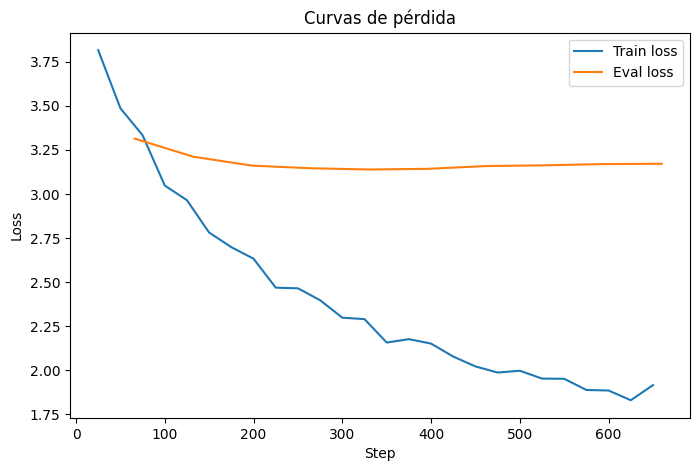

In [22]:
train_logs = logs[logs.get("loss").notnull()] if "loss" in logs.columns else pd.DataFrame()
eval_logs = logs[logs.get("eval_loss").notnull()] if "eval_loss" in logs.columns else pd.DataFrame()

plt.figure(figsize=(8,5))
if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], label="Train loss")
if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Eval loss")
plt.title("Curvas de pérdida")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 13. Comparación antes y después del fine-tuning

In [23]:
comparison_prompts = [
    "Artículo primero:",
    "La presente ley tiene por objeto",
    "Se resuelve que",
    "De conformidad con lo dispuesto en"
]

rows = []

for prompt in comparison_prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    out_base = model_base.generate(
        **inputs,
        max_length=120,
        do_sample=True,
        temperature=0.9,
        top_k=50,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id
    )
    text_base = tokenizer.decode(out_base[0], skip_special_tokens=True)

    out_ft = model_ft.generate(
        **inputs,
        max_length=120,
        do_sample=True,
        temperature=0.9,
        top_k=50,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id
    )
    text_ft = tokenizer.decode(out_ft[0], skip_special_tokens=True)

    rows.append({
        "prompt": prompt,
        "modelo_base": text_base,
        "modelo_fine_tuned": text_ft
    })

comparison_df = pd.DataFrame(rows)
comparison_df

,prompt,modelo_base,modelo_fine_tuned
0,Artículo primero:,Artículo primero: una relación entre los hijos...,"Artículo primero: El Gobierno, mediante Decret..."
1,La presente ley tiene por objeto,La presente ley tiene por objeto limitar el de...,La presente ley tiene por objeto la preservaci...
2,Se resuelve que,Se resuelve que el agua del país sea un blanco...,Se resuelve que la demanda de indemnización no...
3,De conformidad con lo dispuesto en,De conformidad con lo dispuesto en los artícul...,De conformidad con lo dispuesto en este estatu...


In [24]:
for _, row in comparison_df.iterrows():
    print("\n" + "="*120)
    print("PROMPT:", row["prompt"])
    print("\n--- MODELO BASE ---")
    print(row["modelo_base"])
    print("\n--- MODELO FINE-TUNED ---")
    print(row["modelo_fine_tuned"])


PROMPT: Artículo primero:

--- MODELO BASE ---
Artículo primero: una relación entre los hijos de la pareja de actores, incluyendo una breve aparición en el primer episodio de la primera temporada. En la segunda temporada, ella comparte un primer matrimonio con el director Matt Smith, el hermano menor de Paul. Su matrimonio con Smith no se celebró. A pesar de esto, después de la boda, la madre de Smith declaró que se había separado y se había divorciado. Los miembros de la familia se mudaron a la planta de tratamiento de interiores en West Palm Beach, Florida, donde los médicos y el personal médico se trasladaron.

La actuación de la primera

--- MODELO FINE-TUNED ---
Artículo primero: El Gobierno, mediante Decreto Nacional 637 de 1993, declaró a la Agencia Nacional de Tierras de los Recursos Naturales una Unidad Agrícola Familiar, destinada a las actividades agroecológicas, comerciales y de extracción forestal de áreas rurales de los municipios, con el fin de preservar la diversidad é

## 14. Comparación con la función propia después del fine-tuning

In [25]:
for cfg in [
    {"temperature": 0.8, "top_k": 20, "eps": 1.0},
    {"temperature": 0.9, "top_k": 30, "eps": 0.9},
    {"temperature": 1.0, "top_k": 50, "eps": 0.7},
]:
    print("\n" + "#"*100)
    print("Configuración:", cfg)
    print(generate_custom(
        model=model_ft,
        tokenizer=tokenizer,
        prompt="Artículo primero:",
        max_new_tokens=80,
        temperature=cfg["temperature"],
        top_k=cfg["top_k"],
        eps=cfg["eps"],
        device=device
    ))


####################################################################################################
Configuración: {'temperature': 0.8, 'top_k': 20, 'eps': 1.0}
Artículo primero: El Estado debe garantizar la participación de las comunidades negras en los planes, programas y proyectos de desarrollo sustentable, y promover la participación de las comunidades negras en los planes, programas y proyectos de desarrollo sustentable. El Estado debe garantizar la participación de las comunidades negras en los planes, programas y proyectos de desarrollo sustentable, y promover la participación de las comunidades negras en los planes, programas y proyectos de desarrollo sustentable.

####################################################################################################
Configuración: {'temperature': 0.9, 'top_k': 30, 'eps': 0.9}
Artículo primero: El Estado debe garantizar la participación de las comunidades negras en los planes, programas y proyectos de desarrollo sustentable, y p

## 15. Guardar el modelo y el tokenizer ajustados

In [26]:
save_dir = "/content/gpt2_juridico_finetuned"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print("Modelo guardado en:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: /content/gpt2_juridico_finetuned
